# Retail Data Quality — Raw Data Profiling

## Objective

Profile the raw retail sales dataset before performing any cleaning.

The analysis will assess:

- Dataset structure
- Data types
- Missing values
- Duplicate records
- Unique values and cardinality
- Numerical ranges
- Categorical consistency
- Date quality
- Referential integrity
- Financial business-rule consistency

The purpose is to identify, quantify, and prioritize data-quality issues.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)

Project root: d:\GitHub\retail_data_quality_project
Raw data folder: d:\GitHub\retail_data_quality_project\data\raw


In [4]:
sales_path = RAW_DIR / "fact_sales.csv"

sales = pd.read_csv(
    sales_path,
    low_memory=False
)

print("Sales data loaded successfully.")

Sales data loaded successfully.


In [5]:
rows, columns = sales.shape

print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 120,680
Columns: 17


In [6]:
sales.head()

,transaction_id,transaction_date,customer_id,product_id,store_id,quantity,unit_price,discount_amount,gross_sales,net_sales,unit_cost,cost_amount,profit_amount,gross_margin_pct,payment_method,sales_channel,category
0,T000001,2026-07-03 20:07:16.363636,C02583,P0085,S016,1,770.82,0.00,770.82,770.82,635.92,635.92,134.90,17.50,Card,Store,Electronics
1,T000002,2025-04-28 00:00:00.000000,C03663,P0169,S016,3,3819.65,0.00,11458.95,11458.95,2970.08,8910.24,2548.71,22.24,Card,Store,Home Appliances
2,T000003,2025-10-27 00:00:00.000000,C04603,P0442,S017,6,2748.89,0.00,16493.34,16493.34,2430.47,14582.82,1910.52,11.58,Cash,Store,Fashion
3,T000004,2025-03-31 00:00:00.000000,C04661,P0173,S013,7,3621.28,1267.45,25348.96,24081.51,2816.25,19713.75,4367.76,18.14,Card,E-commerce,Home & Living
4,T000005,2025-04-20 00:00:00.000000,C02348,P0442,S009,2,2977.87,297.79,5955.74,5657.95,2430.47,4860.94,797.01,14.09,Mada,Store,Fashion


In [7]:
sales.tail()

,transaction_id,transaction_date,customer_id,product_id,store_id,quantity,unit_price,discount_amount,gross_sales,net_sales,unit_cost,cost_amount,profit_amount,gross_margin_pct,payment_method,sales_channel,category
120675,T089825,2024-05-17 00:00:00.000000,C04038,P0180,S017,4,1601.70,240.26,6406.80,6166.54,1164.00,4656.00,1510.54,23.50,Card,Store,Grocery
120676,T014795,2024-05-23 00:00:00.000000,C01002,P0100,S003,2,2411.53,120.58,4823.06,4702.48,1646.83,3293.66,1408.82,28.12,Cash,Store,Home Appliances
120677,T035268,2024-11-25 00:00:00.000000,C04835,P0138,S012,2,3998.06,0.00,7996.12,7996.12,2940.50,5881.00,2115.12,26.45,Apple Pay,E-commerce,Home & Living
120678,T047154,2024-03-11 00:00:00.000000,C00962,P0337,S014,3,3117.92,311.79,9353.76,9041.97,2332.48,6997.44,2044.53,21.25,Apple Pay,E-commerce,Sports
120679,T008393,2025-04-06 00:00:00.000000,C02205,P0295,S010,4,4437.36,0.00,17749.44,17749.44,2921.00,11684.00,6065.44,34.17,STC Pay,Store,Grocery


In [8]:
sales.sample(10, random_state=42)

,transaction_id,transaction_date,customer_id,product_id,store_id,quantity,unit_price,discount_amount,gross_sales,net_sales,unit_cost,cost_amount,profit_amount,gross_margin_pct,payment_method,sales_channel,category
15245,T015246,2025-12-27 00:00:00.000000,C00596,P0372,S003,4,3024.62,0.00,12098.48,12098.48,2445.02,9780.08,2318.40,19.16,Mada,E-commerce,Home Appliances
39061,T039062,2025-07-18 00:00:00.000000,C01801,P0127,S020,3,928.27,0.00,2784.81,2784.81,738.43,2215.29,569.52,20.45,Mada,Store,Fashion
97894,T097895,2024-08-23 00:00:00.000000,C01259,P0471,S010,3,1809.64,814.34,5428.92,4614.58,1216.45,3649.35,965.23,20.92,Mada,E-commerce,Electronics
21090,T021091,2024-02-11 00:00:00.000000,C03636,P0261,S010,3,839.01,125.85,2517.03,2391.18,731.56,2194.68,196.50,8.22,Card,Store,Home & Living
29156,T029157,2025-07-31 00:00:00.000000,C03548,P0122,S904,3,2430.38,729.11,7291.14,6562.03,1790.51,5371.53,1190.50,18.14,Mada,Store,Grocery
21549,T021550,2024-05-21 00:00:00.000000,C00245,P0139,S012,3,891.47,0.00,2674.41,2674.41,735.63,2206.89,467.52,17.48,Card,E-commerce,Beauty
51781,T051782,2024-05-25 00:00:00.000000,C02990,P0321,S009,2,179.08,17.91,358.16,340.25,114.13,228.26,111.99,32.91,Card,Store,Beauty
118073,T118074,2024-05-31 00:00:00.000000,C01714,P0113,S019,2,1368.26,0.00,2736.52,2736.52,897.59,1795.18,941.34,34.40,Card,Store,Fashion
24159,T024160,2025-01-27 00:00:00.000000,C02437,P0388,S008,3,3273.05,981.92,9819.15,8837.23,2471.39,7414.17,1423.06,16.10,Card,Store,Electronics
36556,T036557,2024-12-19 00:00:00.000000,C03752,P0344,S005,3,1495.97,673.19,4487.91,3814.72,1024.27,3072.81,741.91,19.45,Mada,Store,Home & Living


In [9]:
sales.columns.tolist()

['transaction_id',
 'transaction_date',
 'customer_id',
 'product_id',
 'store_id',
 'quantity',
 'unit_price',
 'discount_amount',
 'gross_sales',
 'net_sales',
 'unit_cost',
 'cost_amount',
 'profit_amount',
 'gross_margin_pct',
 'payment_method',
 'sales_channel',
 'category']

In [10]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 120680 entries, 0 to 120679
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    120680 non-null  str    
 1   transaction_date  120530 non-null  str    
 2   customer_id       120077 non-null  str    
 3   product_id        120680 non-null  str    
 4   store_id          120680 non-null  str    
 5   quantity          120680 non-null  int64  
 6   unit_price        120680 non-null  float64
 7   discount_amount   120680 non-null  float64
 8   gross_sales       120680 non-null  float64
 9   net_sales         120680 non-null  float64
 10  unit_cost         120680 non-null  float64
 11  cost_amount       120680 non-null  float64
 12  profit_amount     120680 non-null  float64
 13  gross_margin_pct  120680 non-null  float64
 14  payment_method    120319 non-null  str    
 15  sales_channel     120680 non-null  str    
 16  category          120530 non-nu

In [11]:
quality_report = pd.DataFrame({
    "column": sales.columns,
    "data_type": sales.dtypes.astype(str).values,
    "non_null": sales.notna().sum().values,
    "missing": sales.isna().sum().values
})

quality_report["missing_pct"] = (
    quality_report["missing"]
    / len(sales)
    * 100
).round(2)

quality_report

,column,data_type,non_null,missing,missing_pct
0,transaction_id,str,120680,0,0.00
1,transaction_date,str,120530,150,0.12
2,customer_id,str,120077,603,0.50
3,product_id,str,120680,0,0.00
4,store_id,str,120680,0,0.00
5,quantity,int64,120680,0,0.00
6,unit_price,float64,120680,0,0.00
7,discount_amount,float64,120680,0,0.00
8,gross_sales,float64,120680,0,0.00
9,net_sales,float64,120680,0,0.00


In [12]:
missing_summary = (
    sales.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary

customer_id         603
payment_method      361
category            150
transaction_date    150
transaction_id        0
quantity              0
unit_price            0
product_id            0
store_id              0
gross_sales           0
discount_amount       0
net_sales             0
unit_cost             0
profit_amount         0
cost_amount           0
gross_margin_pct      0
sales_channel         0
dtype: int64

In [14]:
missing_pct = (
    sales.isna().mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

missing_pct

customer_id         0.50
payment_method      0.30
category            0.12
transaction_date    0.12
transaction_id      0.00
quantity            0.00
unit_price          0.00
product_id          0.00
store_id            0.00
gross_sales         0.00
discount_amount     0.00
net_sales           0.00
unit_cost           0.00
profit_amount       0.00
cost_amount         0.00
gross_margin_pct    0.00
sales_channel       0.00
dtype: float64

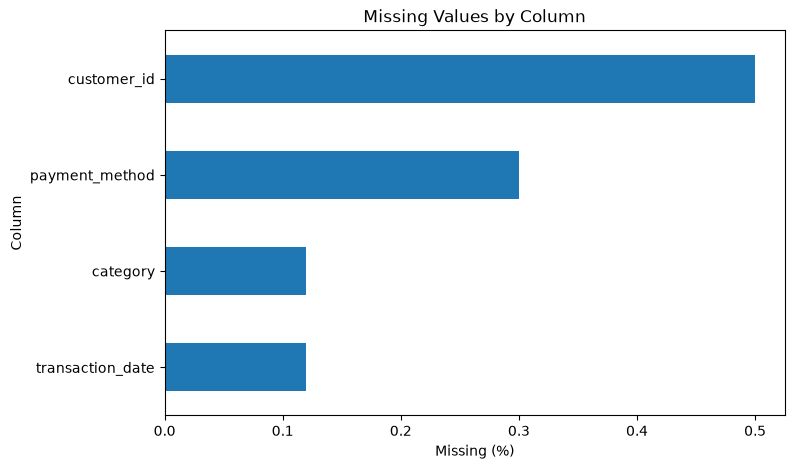

In [15]:
import matplotlib.pyplot as plt

missing_pct = (
    sales.isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_pct_nonzero = (
    missing_pct[missing_pct > 0]
    .sort_values()
)

missing_pct_nonzero.plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Missing Values by Column")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.show()

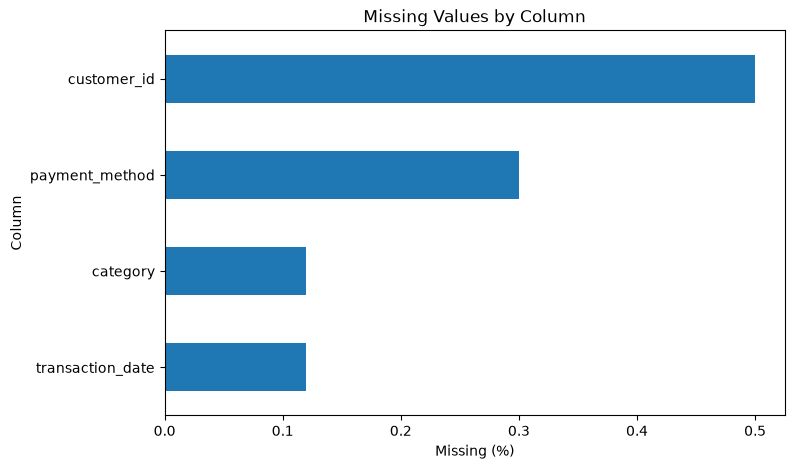

In [16]:
import matplotlib.pyplot as plt

missing_pct_nonzero = (
    missing_pct[missing_pct > 0]
    .sort_values()
)

missing_pct_nonzero.plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Missing Values by Column")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.show()

In [17]:
exact_duplicates = sales.duplicated().sum()

print(
    f"Exact duplicate rows: {exact_duplicates:,}"
)

Exact duplicate rows: 469


In [18]:
categorical_columns = [
    "customer_id",
    "product_id",
    "store_id",
    "payment_method",
    "sales_channel",
    "category"
]

cardinality_report = pd.DataFrame({
    "column": categorical_columns,
    "unique_values": [
        sales[col].nunique(dropna=True)
        for col in categorical_columns
    ]
})

cardinality_report

,column,unique_values
0,customer_id,5150
1,product_id,637
2,store_id,88
3,payment_method,5
4,sales_channel,2
5,category,22


In [19]:
sales["payment_method"].value_counts(
    dropna=False
)

payment_method
Card         41808
Mada         30396
Cash         18102
Apple Pay    18005
STC Pay      12008
NaN            361
Name: count, dtype: int64

In [20]:
sales["payment_method"].value_counts(
    normalize=True,
    dropna=False
).mul(100).round(2)

payment_method
Card         34.64
Mada         25.19
Cash         15.00
Apple Pay    14.92
STC Pay       9.95
NaN           0.30
Name: proportion, dtype: float64

In [21]:
numeric_columns = [
    "quantity",
    "discount_amount",
    "gross_sales",
    "net_sales",
    "unit_cost",
    "cost_amount",
    "profit_amount",
    "gross_margin_pct"
]

In [22]:
sales[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
quantity,120680.0,2.985159,1.454949,-8.00,2.0000,3.000,4.0000,10.00
discount_amount,120680.0,328.299913,676.579150,0.00,0.0000,71.420,444.1425,29002.81
gross_sales,120680.0,6304.406748,4943.278541,53.50,2471.0950,5194.000,8922.9375,48319.70
net_sales,120680.0,5988.534941,4720.363967,43.22,2343.2400,4910.595,8486.4875,48319.70
unit_cost,120680.0,1523.569219,840.496401,40.72,760.7700,1590.580,2202.0300,2991.82
cost_amount,120680.0,4578.241714,3525.855920,40.72,1833.0800,3811.230,6511.0800,29306.40
profit_amount,120680.0,1409.699591,1423.431914,-1810.86,385.8875,970.410,1984.7475,19109.70
gross_margin_pct,120680.0,22.297456,9.397454,-14.34,15.9200,23.270,29.6800,40.40


In [23]:
sales["quantity"].describe()

count    120680.000000
mean          2.985159
std           1.454949
min          -8.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          10.000000
Name: quantity, dtype: float64

In [24]:
print(
    "Negative quantity:",
    (sales["quantity"] < 0).sum()
)

print(
    "Zero quantity:",
    (sales["quantity"] == 0).sum()
)

Negative quantity: 300
Zero quantity: 200


In [25]:
numeric_price = pd.to_numeric(
    sales["unit_price"],
    errors="coerce"
)

non_numeric_price = sales[
    numeric_price.isna()
]

non_numeric_price[
    ["transaction_id", "unit_price"]
].head(20)

,transaction_id,unit_price


In [26]:
print(
    "Non-numeric unit prices:",
    numeric_price.isna().sum()
)

Non-numeric unit prices: 0


In [27]:
sales["transaction_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [28]:
sales["transaction_date"].head()

0    2026-07-03 20:07:16.363636
1    2025-04-28 00:00:00.000000
2    2025-10-27 00:00:00.000000
3    2025-03-31 00:00:00.000000
4    2025-04-20 00:00:00.000000
Name: transaction_date, dtype: str

In [29]:
parsed_dates = pd.to_datetime(
    sales["transaction_date"],
    errors="coerce"
)

In [30]:
print(
    "Unparseable/missing dates:",
    parsed_dates.isna().sum()
)

Unparseable/missing dates: 150


In [31]:
print("Minimum date:", parsed_dates.min())
print("Maximum date:", parsed_dates.max())

Minimum date: 2024-01-01 00:00:00
Maximum date: 2026-12-31 00:00:00


In [32]:
expected_max_date = pd.Timestamp("2025-12-31")

In [33]:
future_dates = parsed_dates > expected_max_date

print(
    "Future-dated transactions:",
    future_dates.sum()
)

Future-dated transactions: 100


In [34]:
products = pd.read_csv(
    RAW_DIR / "dim_product.csv"
)

In [35]:
valid_product_ids = set(
    products["product_id"]
)

In [36]:
orphan_products = ~sales["product_id"].isin(
    valid_product_ids
)

print(
    "Orphan product IDs:",
    orphan_products.sum()
)

Orphan product IDs: 150


In [39]:
customers = pd.read_csv(
    RAW_DIR / "dim_customer.csv"
)


In [40]:
valid_customer_ids = set(
    customers["customer_id"]
)

In [41]:
orphan_customers = (
    sales["customer_id"].notna()
    & ~sales["customer_id"].isin(valid_customer_ids)
)

print(
    "Orphan customer IDs:",
    orphan_customers.sum()
)

Orphan customer IDs: 150


In [42]:
stores = pd.read_csv(
    RAW_DIR / "dim_store.csv"
)

In [43]:
valid_store_ids = set(
    stores["store_id"]
)

In [44]:
orphan_stores = (
    ~sales["store_id"].isin(valid_store_ids)
)

print(
    "Orphan store IDs:",
    orphan_stores.sum()
)

Orphan store IDs: 100


In [45]:
price_numeric = pd.to_numeric(
    sales["unit_price"],
    errors="coerce"
)

In [46]:
expected_gross_sales = (
    sales["quantity"]
    * price_numeric
).round(2)

In [47]:
gross_sales_mismatch = (
    ~np.isclose(
        sales["gross_sales"],
        expected_gross_sales,
        equal_nan=False
    )
)

print(
    "Gross sales mismatches:",
    gross_sales_mismatch.sum()
)

Gross sales mismatches: 896


In [48]:
expected_net_sales = (
    sales["gross_sales"]
    - sales["discount_amount"]
).round(2)

net_sales_mismatch = (
    ~np.isclose(
        sales["net_sales"],
        expected_net_sales,
        equal_nan=False
    )
)

print(
    "Net sales mismatches:",
    net_sales_mismatch.sum()
)

Net sales mismatches: 450


In [49]:
expected_profit = (
    sales["net_sales"]
    - sales["cost_amount"]
).round(2)

profit_mismatch = (
    ~np.isclose(
        sales["profit_amount"],
        expected_profit,
        equal_nan=False
    )
)

print(
    "Profit mismatches:",
    profit_mismatch.sum()
)

Profit mismatches: 250


In [50]:
invalid_discounts = (
    sales["discount_amount"] < 0
) | (
    sales["discount_amount"]
    > sales["gross_sales"]
)

print(
    "Invalid discounts:",
    invalid_discounts.sum()
)

Invalid discounts: 200


In [51]:
expected_margin = np.where(
    sales["net_sales"] != 0,
    (
        sales["profit_amount"]
        / sales["net_sales"]
        * 100
    ),
    np.nan
)

In [52]:
margin_mismatch = (
    ~np.isclose(
        sales["gross_margin_pct"],
        expected_margin,
        equal_nan=True
    )
)

print(
    "Gross margin mismatches:",
    margin_mismatch.sum()
)

Gross margin mismatches: 115327


In [53]:
data_quality_findings = pd.DataFrame([
    {
        "issue": "Missing customer_id",
        "column": "customer_id",
        "records": sales["customer_id"].isna().sum(),
        "percentage": sales["customer_id"].isna().mean() * 100
    },
    {
        "issue": "Missing payment_method",
        "column": "payment_method",
        "records": sales["payment_method"].isna().sum(),
        "percentage": sales["payment_method"].isna().mean() * 100
    },
    {
        "issue": "Missing transaction_date",
        "column": "transaction_date",
        "records": sales["transaction_date"].isna().sum(),
        "percentage": sales["transaction_date"].isna().mean() * 100
    },
    {
        "issue": "Exact duplicate rows",
        "column": "all columns",
        "records": sales.duplicated().sum(),
        "percentage": sales.duplicated().mean() * 100
    },
    {
        "issue": "Duplicate transaction IDs",
        "column": "transaction_id",
        "records": sales["transaction_id"].duplicated().sum(),
        "percentage": sales["transaction_id"].duplicated().mean() * 100
    },
    {
        "issue": "Negative quantity",
        "column": "quantity",
        "records": (sales["quantity"] < 0).sum(),
        "percentage": (sales["quantity"] < 0).mean() * 100
    },
    {
        "issue": "Zero quantity",
        "column": "quantity",
        "records": (sales["quantity"] == 0).sum(),
        "percentage": (sales["quantity"] == 0).mean() * 100
    },
    {
        "issue": "Non-numeric unit price",
        "column": "unit_price",
        "records": numeric_price.isna().sum(),
        "percentage": numeric_price.isna().mean() * 100
    },
    {
        "issue": "Future transaction date",
        "column": "transaction_date",
        "records": future_dates.sum(),
        "percentage": future_dates.mean() * 100
    },
    {
        "issue": "Orphan product ID",
        "column": "product_id",
        "records": orphan_products.sum(),
        "percentage": orphan_products.mean() * 100
    },
    {
        "issue": "Orphan customer ID",
        "column": "customer_id",
        "records": orphan_customers.sum(),
        "percentage": orphan_customers.mean() * 100
    },
    {
        "issue": "Orphan store ID",
        "column": "store_id",
        "records": orphan_stores.sum(),
        "percentage": orphan_stores.mean() * 100
    },
    {
        "issue": "Gross sales mismatch",
        "column": "gross_sales",
        "records": gross_sales_mismatch.sum(),
        "percentage": gross_sales_mismatch.mean() * 100
    },
    {
        "issue": "Net sales mismatch",
        "column": "net_sales",
        "records": net_sales_mismatch.sum(),
        "percentage": net_sales_mismatch.mean() * 100
    },
    {
        "issue": "Profit mismatch",
        "column": "profit_amount",
        "records": profit_mismatch.sum(),
        "percentage": profit_mismatch.mean() * 100
    },
    {
        "issue": "Invalid discount",
        "column": "discount_amount",
        "records": invalid_discounts.sum(),
        "percentage": invalid_discounts.mean() * 100
    },
    {
        "issue": "Gross margin mismatch",
        "column": "gross_margin_pct",
        "records": margin_mismatch.sum(),
        "percentage": margin_mismatch.mean() * 100
    }
])

data_quality_findings["percentage"] = (
    data_quality_findings["percentage"]
    .round(2)
)

data_quality_findings

,issue,column,records,percentage
0,Missing customer_id,customer_id,603,0.50
1,Missing payment_method,payment_method,361,0.30
2,Missing transaction_date,transaction_date,150,0.12
3,Exact duplicate rows,all columns,469,0.39
4,Duplicate transaction IDs,transaction_id,680,0.56
5,Negative quantity,quantity,300,0.25
6,Zero quantity,quantity,200,0.17
7,Non-numeric unit price,unit_price,0,0.00
8,Future transaction date,transaction_date,100,0.08
9,Orphan product ID,product_id,150,0.12


In [54]:
business_impacts = {
    "Missing customer_id":
        "Prevents reliable customer-level analysis and segmentation.",
    "Missing payment_method":
        "Reduces accuracy of payment-method reporting.",
    "Missing transaction_date":
        "Can distort daily, monthly, and time-based sales analysis.",
    "Exact duplicate rows":
        "Can overstate revenue, transactions, units, and profit.",
    "Duplicate transaction IDs":
        "May represent duplicate or conflicting transaction records.",
    "Negative quantity":
        "May indicate invalid sales records or an unmodeled return.",
    "Zero quantity":
        "Can create transactions with inconsistent financial values.",
    "Non-numeric unit price":
        "Prevents reliable financial calculations.",
    "Future transaction date":
        "Can distort reporting periods and time intelligence.",
    "Orphan product ID":
        "Prevents reliable product/category attribution.",
    "Orphan customer ID":
        "Prevents reliable customer attribution.",
    "Orphan store ID":
        "Prevents reliable store performance reporting.",
    "Gross sales mismatch":
        "Can directly overstate or understate sales.",
    "Net sales mismatch":
        "Can produce incorrect revenue KPIs.",
    "Profit mismatch":
        "Can produce incorrect profitability reporting.",
    "Invalid discount":
        "Can produce impossible or misleading net-sales values.",
    "Gross margin mismatch":
        "Can produce incorrect profitability KPIs."
}

data_quality_findings["business_impact"] = (
    data_quality_findings["issue"]
    .map(business_impacts)
)

data_quality_findings

,issue,column,records,percentage,business_impact
0,Missing customer_id,customer_id,603,0.50,Prevents reliable customer-level analysis and ...
1,Missing payment_method,payment_method,361,0.30,Reduces accuracy of payment-method reporting.
2,Missing transaction_date,transaction_date,150,0.12,"Can distort daily, monthly, and time-based sal..."
3,Exact duplicate rows,all columns,469,0.39,"Can overstate revenue, transactions, units, an..."
4,Duplicate transaction IDs,transaction_id,680,0.56,May represent duplicate or conflicting transac...
5,Negative quantity,quantity,300,0.25,May indicate invalid sales records or an unmod...
6,Zero quantity,quantity,200,0.17,Can create transactions with inconsistent fina...
7,Non-numeric unit price,unit_price,0,0.00,Prevents reliable financial calculations.
8,Future transaction date,transaction_date,100,0.08,Can distort reporting periods and time intelli...
9,Orphan product ID,product_id,150,0.12,Prevents reliable product/category attribution.


In [55]:
severity_map = {
    "Missing customer_id": "Medium",
    "Missing payment_method": "Low",
    "Missing transaction_date": "High",
    "Exact duplicate rows": "Critical",
    "Duplicate transaction IDs": "Critical",
    "Negative quantity": "High",
    "Zero quantity": "High",
    "Non-numeric unit price": "High",
    "Future transaction date": "High",
    "Orphan product ID": "High",
    "Orphan customer ID": "Medium",
    "Orphan store ID": "High",
    "Gross sales mismatch": "Critical",
    "Net sales mismatch": "Critical",
    "Profit mismatch": "Critical",
    "Invalid discount": "High",
    "Gross margin mismatch": "High"
}

data_quality_findings["severity"] = (
    data_quality_findings["issue"]
    .map(severity_map)
)

In [56]:
data_quality_findings.sort_values(
    ["severity", "records"],
    ascending=[True, False]
)

,issue,column,records,percentage,business_impact,severity
12,Gross sales mismatch,gross_sales,896,0.74,Can directly overstate or understate sales.,Critical
4,Duplicate transaction IDs,transaction_id,680,0.56,May represent duplicate or conflicting transac...,Critical
3,Exact duplicate rows,all columns,469,0.39,"Can overstate revenue, transactions, units, an...",Critical
13,Net sales mismatch,net_sales,450,0.37,Can produce incorrect revenue KPIs.,Critical
14,Profit mismatch,profit_amount,250,0.21,Can produce incorrect profitability reporting.,Critical
16,Gross margin mismatch,gross_margin_pct,115327,95.56,Can produce incorrect profitability KPIs.,High
5,Negative quantity,quantity,300,0.25,May indicate invalid sales records or an unmod...,High
6,Zero quantity,quantity,200,0.17,Can create transactions with inconsistent fina...,High
15,Invalid discount,discount_amount,200,0.17,Can produce impossible or misleading net-sales...,High
2,Missing transaction_date,transaction_date,150,0.12,"Can distort daily, monthly, and time-based sal...",High


In [57]:
report_path = (
    PROJECT_ROOT
    / "docs"
    / "data_quality_report.csv"
)

data_quality_findings.to_csv(
    report_path,
    index=False
)

print(f"Data quality report saved to: {report_path}")

Data quality report saved to: d:\GitHub\retail_data_quality_project\docs\data_quality_report.csv
